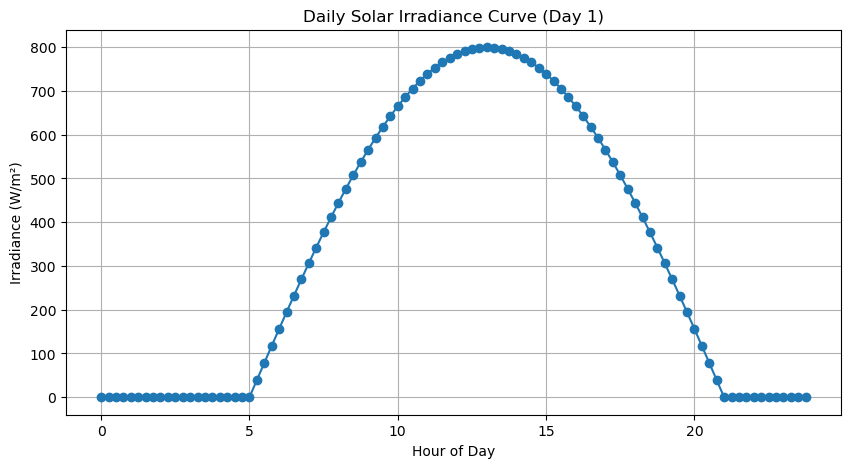

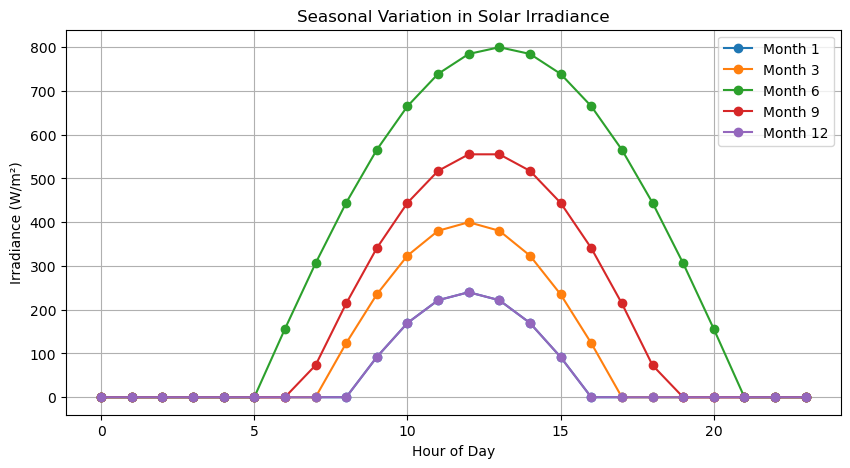

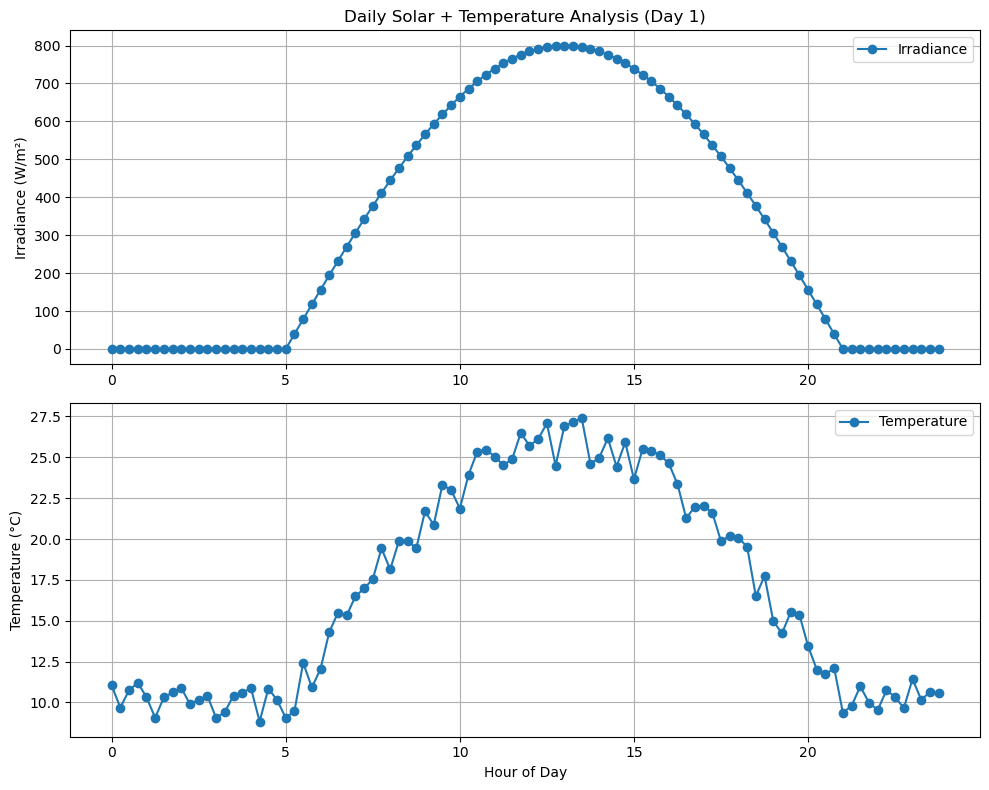

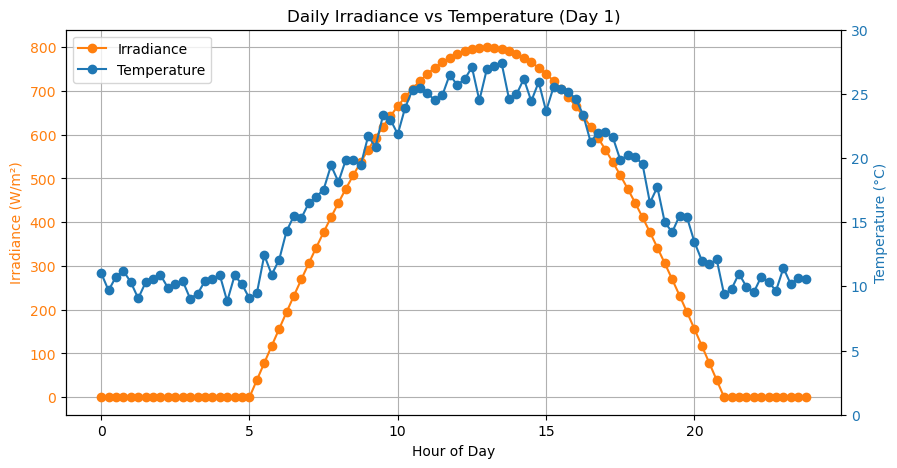

Dataset sample: 
[{'day': 1, 'hour': 0.0, 'irradiance': 0, 'temperature': 11.048753270419919}, {'day': 1, 'hour': 0.25, 'irradiance': 0, 'temperature': 9.68393372783486}, {'day': 1, 'hour': 0.5, 'irradiance': 0, 'temperature': 10.74555359811282}, {'day': 1, 'hour': 0.75, 'irradiance': 0, 'temperature': 11.209847227579152}, {'day': 1, 'hour': 1.0, 'irradiance': 0, 'temperature': 10.330566329280497}, {'day': 1, 'hour': 1.25, 'irradiance': 0, 'temperature': 9.066454996973592}, {'day': 1, 'hour': 1.5, 'irradiance': 0, 'temperature': 10.31103072794974}, {'day': 1, 'hour': 1.75, 'irradiance': 0, 'temperature': 10.611857514977782}, {'day': 1, 'hour': 2.0, 'irradiance': 0, 'temperature': 10.887423522617906}, {'day': 1, 'hour': 2.25, 'irradiance': 0, 'temperature': 9.899121528704987}, {'day': 1, 'hour': 2.5, 'irradiance': 0, 'temperature': 10.164551693794792}, {'day': 1, 'hour': 2.75, 'irradiance': 0, 'temperature': 10.418331170679853}]



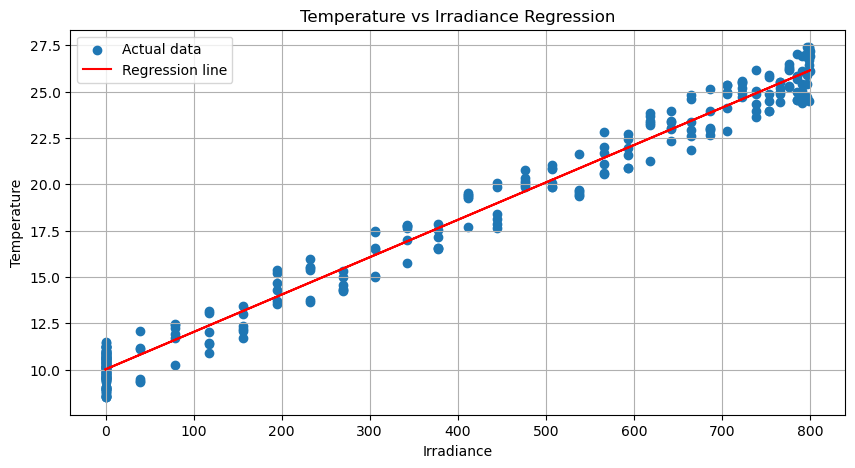

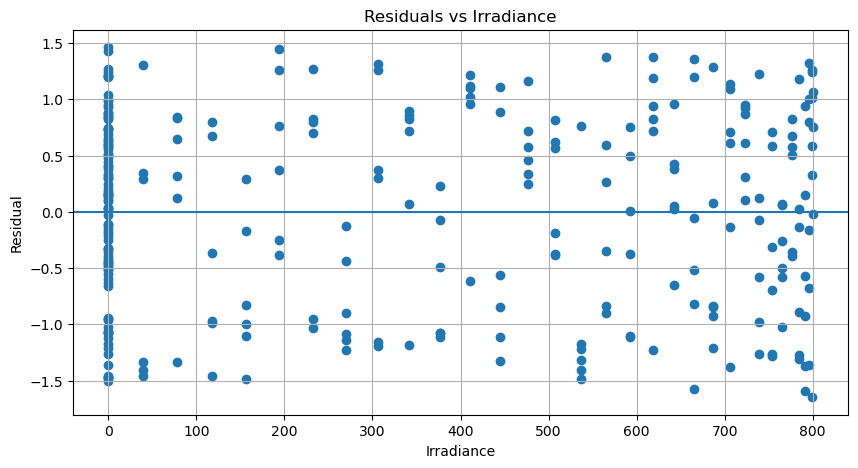

Slope: 0.020178575792418434
Intercept: 10.010299965659588
MSE: 0.743
RMSE: 0.862
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]
[11.04875327  9.68393373 10.7455536  11.20984723 10.33056633]
(288, 1)
(288,)
[[0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [3.92541395e+01]
 [7.84137123e+01]
 [1.17384380e+02]
 [1.56072258e+02]
 [1.94384144e+02]
 [2.32227742e+02]
 [2.69511883e+02]
 [3.06146746e+02]
 [3.42044075e+02]
 [3.77117389e+02]
 [4.11282195e+02]
 [4.44456186e+02]
 [4.76559444e+02]
 [5.07514627e+02]
 [5.37247164e+02]
 [5.65685425e+02]
 [5.92760900e+02]
 [6.18408363e+02]
 [6.42566025e+02]
 [6.65175690e+02]
 [6.86182888e+02]
 [7.05

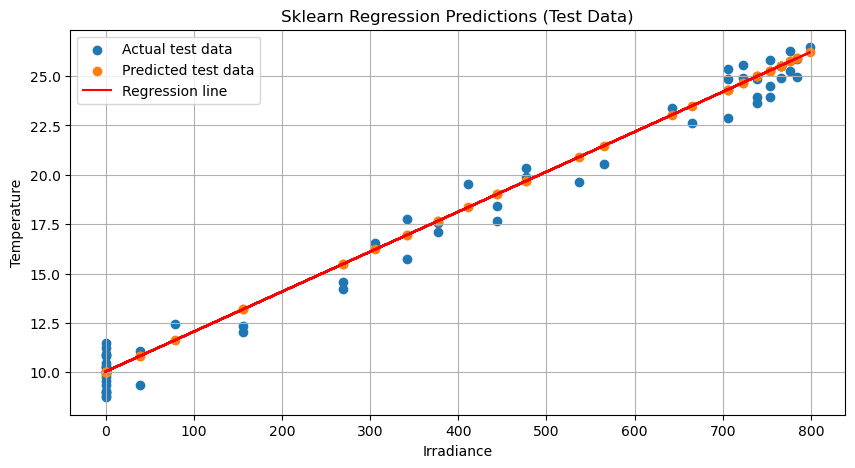

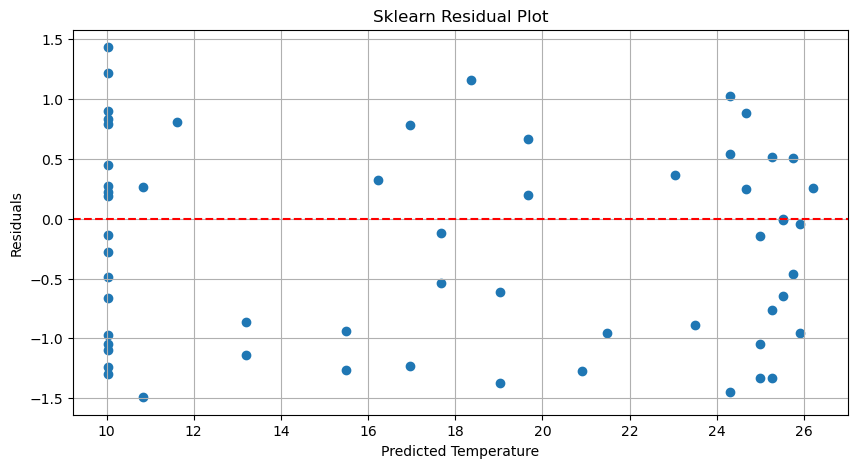

In [13]:
import math
import matplotlib.pyplot as plt
import random
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression   #Computes best fit line, minimises squared error, learns slope + intercept

{
    "date": "YYYY-MM-DD",         #String
    "hour": int,                 #Integer
    "temperature": float,
    "irradiance": float
}

def seasonal_factor(month):
    """Models a seasonal factor, where irradiance is stronger in summer months"""
    if month in [6, 7]:
        return 1.0              # peak summer
    elif month in [4, 5, 8, 9]:
        return 0.7              # spring/autumn
    elif month in [2, 3, 10, 11]:
        return 0.5              # transitional months
    elif month in [12, 1]:
        return 0.3              # winter
    else:
        return 0.5              #Safety fallback

def daylight_hours(month):
    """Models longr dylight hours in summer, shorter in winter"""
    
    if month in [6, 7]:
        return 5, 21               #Sunrise 5am, sunset 9pm

    elif month in [4, 5, 8, 9]:
        return 6.5, 18.5           #Sunrise 6.30am, sunset 6.30pm

    elif month in [2, 3, 10, 11]:
        return 7, 17               #Sunrise 7am, sunset 5pm

    elif month in [12, 1]:
        return 8, 16               #Sunrise 8am, sunset 4pm

    else:
        return 6, 18

def compute_irradiance(hour, month):
    """Calculates irradiance based on equation I = A((pi/12)*(h-6))
    where A = max irradiance, h = hour (0-24) 
    and 12 is the number of hours of sunlight, 
    assuming sunrise at 6am, and sunset at 6pm"""

    A = 800                                  #Max irradiance = 800W/m²
    
    sunrise, sunset = daylight_hours(month)
    if hour < sunrise or hour > sunset:
        return 0                              #Nighttime returns zero irradiance

    day_length = sunset - sunrise

    angle = (math.pi / day_length) * (hour - sunrise)

    base = math.sin(angle)

    irradiance = A * base

    return max(0, irradiance * seasonal_factor(month))   #Return whichever is bigger: 0 or value

def compute_temperature(irradiance, noise_range):
    """Calculates temperature based on level of irradiance, 
    with a base level of 10 degrees C"""

    base_temp = 10  # typical baseline (°C)

    signal = base_temp + (irradiance * 0.02)

    noise = random.uniform(-noise_range, noise_range)   # Generate a random decimal number in the noise range

    temp = signal + noise

    return temp

def generate_dataset(month, noise_range):
    """Generates set of data including day, hour, irradiance and temperature"""
    
    dataset = []
    
    for day in range(1, 4):        #Generates data for the days given (here the first 3 (1, 4)
        for step in range(96):     #Generates data every 15 mins (24 hours * 4 = 96)
            
            hour = step / 4        #Every 4 '15 min block' (ie step) = 1 hour
            
            record = {}
            record["day"] = day
            record["hour"] = hour
        
            # Irradiance
            irr = compute_irradiance(hour, month)
            record["irradiance"] = irr
            
            # Temperature (NEW)
            record["temperature"] = compute_temperature(irr, noise_range)
    
            dataset.append(record)
           
    return dataset

def filter_by_value(dataset, key, value):
    """Filters dataset by a given value"""
    
    result = []
    
    for r in dataset:
        if r[key] == value:
            result.append(r)
    
    return result

# --------------------------------
# Initial model plotting functions
# --------------------------------

def plot_daily_irradiance(dataset, day_value):

    day_data = filter_by_value(dataset, "day", day_value)

    hours = []
    irradiance = []

    for r in day_data:
        hours.append(r["hour"])
        irradiance.append(r["irradiance"])

    plt.figure(figsize=(10,5))
    plt.plot(hours, irradiance, marker="o")

    plt.xlabel("Hour of Day")
    plt.ylabel("Irradiance (W/m²)")
    plt.title(f"Daily Solar Irradiance Curve (Day {day_value})")

    plt.grid(True)

    plt.savefig("daily_solar_irradiance_curve.png", dpi=300)
    plt.show()
    
def plot_seasonal_irradiance(months):

    plt.figure(figsize=(10,5))

    for month in months:

        hours = []
        irradiance = []

        for hour in range(24):

            hours.append(hour)

            irr = compute_irradiance(hour, month)
            irradiance.append(irr)

        plt.plot(
            hours,
            irradiance,
            marker="o",
            label=f"Month {month}"
        )

    plt.xlabel("Hour of Day")
    plt.ylabel("Irradiance (W/m²)")
    plt.title("Seasonal Variation in Solar Irradiance")

    plt.grid(True)
    plt.legend()

    plt.savefig(
        "seasonal_variation_in_solar_irradiance.png",
        dpi=300
    )

    plt.show()
    
def plot_daily_analysis(dataset, day_value):
    day_data = []

    for r in dataset:
        if r["day"] == day_value:
            day_data.append(r)

    hours = []
    irradiance = []
    temperature = []

    for r in day_data:
        hours.append(r["hour"])
        irradiance.append(r["irradiance"])
        temperature.append(r["temperature"])

    fig, axes = plt.subplots(2, 1, figsize=(10,8))   #Creates two separate plots, based on same dataset analysis

    # ------------------------
    # Top plot: Irradiance                           #Each plot needs its own axis defining
    # ------------------------
    axes[0].plot(hours, irradiance, label="Irradiance", marker="o")
    axes[0].set_title(f"Daily Solar + Temperature Analysis (Day {day_value})")
    axes[0].set_ylabel("Irradiance (W/m²)")
    axes[0].grid(True)
    axes[0].legend()

    # ------------------------
    # Bottom plot: Temperature
    # ------------------------
    axes[1].plot(hours, temperature, label="Temperature", marker="o")
    axes[1].set_xlabel("Hour of Day")
    axes[1].set_ylabel("Temperature (°C)")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("daily_solar_and_temperature_analysis.png", dpi=300) 
    plt.show()
   
def plot_daily_twin_axis(dataset, day_value):   
    """Plts both irradiance and temp on same graph, different y-axes"""
    # -----------------------------
    # Filter data for selected day
    # -----------------------------
    day_data = []

    for r in dataset:
        if r["day"] == day_value:
            day_data.append(r)

    # -----------------------------
    # Extract lists
    # -----------------------------
    hours = []
    irradiance = []
    temperature = []

    for r in day_data:
        hours.append(r["hour"])
        irradiance.append(r["irradiance"])
        temperature.append(r["temperature"])

    # -----------------------------
    # Create figure + primary axis
    # -----------------------------
    fig, ax1 = plt.subplots(figsize=(10,5))

    # Irradiance (left axis)
    ax1.plot(hours, irradiance, color="tab:orange", marker="o", label="Irradiance")
    ax1.set_xlabel("Hour of Day")
    ax1.set_ylabel("Irradiance (W/m²)", color="tab:orange")
    ax1.tick_params(axis='y', labelcolor="tab:orange")
    ax1.grid(True)

    # -----------------------------
    # Secondary axis (temperature)
    # -----------------------------
    ax2 = ax1.twinx()

    ax2.set_ylim(0, 30)          #Sets different height of second y-axis so plots don't overlap.
    ax2.plot(hours, temperature, color="tab:blue", marker="o", label="Temperature")
    ax2.set_ylabel("Temperature (°C)", color="tab:blue")
    ax2.tick_params(axis='y', labelcolor="tab:blue")

    # -----------------------------
    # Title + layout
    # -----------------------------
    plt.title(f"Daily Irradiance vs Temperature (Day {day_value})")

    # Optional: combined legend handling
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    plt.savefig("daily_irradiance_vs_temperature.png", dpi=300) 
    plt.show()

# -----------------------------
# Reusable Regression Pipeline                  # x_values and y_values can be used for multiple different variables
# -----------------------------

def extract_regression_variables(dataset):
    """Extract inputs and targets for regression"""

    x_values = []
    y_values = []

    for record in dataset:
        x_values.append(record["irradiance"])
        y_values.append(record["temperature"])

    return x_values, y_values

def compute_mean(values):
    """Compute the mean of a list of numeric values."""
    total = 0
    count = 0

    for value in values:
        if value is not None:
            total += value
            count += 1

    if count == 0:
        return None

    average = total / count
    return average
    
def fit_linear_regression(x_values, y_values):  
    """Regression parameter calculation"""
    
    mean_x = compute_mean(x_values)
    mean_y = compute_mean(y_values)

    products = []
    x_squares = []

    for x, y in zip(x_values, y_values):
        dx = x - mean_x
        dy = y - mean_y
        products.append(dx * dy)
        x_squares.append(dx * dx)

    sum_products = sum(products)
    sum_x_squares = sum(x_squares)

    m = sum_products / sum_x_squares
    b = mean_y - m * mean_x

    return m, b, mean_x, mean_y

def predict(x_values, m, b):           #Using the parameter x_values means we can apply this function to any dataset/variable
    """Prediction generation"""
    
    predicted_values = []

    for x in x_values:
        y_hat = m * x + b
        predicted_values.append(y_hat)

    return predicted_values

def compute_mse(x_values, y_values, m, b):    
    """Evaluation metrics (MSE/RMSE calculations)"""
    
    squared_errors = []

    for x, y in zip(x_values, y_values):
        y_hat = m * x + b              
        error = y - y_hat              #The residual - difference between predicted value (y_hat) and actual measured value (y)
        squared_error = error ** 2     #Errors are squared so that +ve and -ve erors don't cancel out
        squared_errors.append(squared_error)   
   
    mse = sum(squared_errors) / len(squared_errors)   #Mean squared error (MSE) - the average of the squared errors in °C²
    rmse = math.sqrt(mse)                             #Square root of MSE, gives the error in °C
    
    return mse, rmse

def compute_residuals(x_values, y_values, m, b):     #Residual analysis - residuals, positive/negative split  
    
    residuals = []

    for x, y in zip(x_values, y_values):
        y_hat = m * x + b
        residual = y - y_hat      #Residual same as error (difference between y_hat and y)
        residuals.append(residual)

    return residuals

def run_linear_regression_pipeline(dataset):
    """Automates a reusable regression system into a structured results object:
    Feature extraction
    Model fitting
    Prediction generation
    Error evaluation"""

    # Feature extraction
    x_values, y_values = extract_regression_variables(dataset)
    
    # Fit linear model
    m, b, mean_x, mean_y = fit_linear_regression(x_values, y_values)
    
    # Predictions
    predicted_y = predict(x_values, m, b)  

    #Evaluation
    mse, rmse = compute_mse(x_values, y_values, m, b)

    residuals = compute_residuals(x_values, y_values, m, b)

    #Return results
    return {
        "m": m,
        "b": b,
        "mse": mse,
        "rmse": rmse,
        "predicted_y": predicted_y,
        "x_values": x_values,
        "y_values": y_values,
        "residuals": residuals
    }
  
def plot_regression_line(x_values, y_values, predicted_y):
    """Plot x and y values against regression line (x values vs predicted y values)"""
    
    plt.figure(figsize=(10,5))

    plt.scatter(x_values, y_values, label="Actual data")

    plt.plot(x_values, predicted_y, color="red", label="Regression line")

    plt.xlabel("Irradiance")
    plt.ylabel("Temperature")

    plt.title("Temperature vs Irradiance Regression")

    plt.grid(True)
    plt.legend()

    plt.savefig("irradiance_temperature_regression.png", dpi=300)

    plt.show()

def plot_residuals(x_values, residuals):
    """Visualise errors (residuals)"""
    
    plt.figure(figsize=(10,5))

    plt.scatter(x_values, residuals)

    plt.axhline(0)         #Puts horizoatal marker line at y=0

    plt.xlabel("Irradiance")
    plt.ylabel("Residual")

    plt.title("Residuals vs Irradiance")

    plt.grid(True)

    plt.savefig("residuals_vs_irradiance.png", dpi=300)

    plt.show()

def run_sklearn_regression_pipeline(dataset):

    # Extract variables
    x_values, y_values = extract_regression_variables(dataset)

    # Convert to NumPy arrays
    X = np.array(x_values)                     #Converts lists into arrays for use with NumPy
    y = np.array(y_values)

    # Reshape feature matrix
    X = X.reshape(-1, 1)                       #-1 - Allows NumPy to automatically determine the correct number of rows, 1 - one column

    #Temporary print commands for visualising data
    print(type(X))
    print(type(y))

    print(X[:5])
    print(y[:5])

    print(X.shape)
    print(y.shape)

    print(X)
    print(X.reshape(-1,1))

    #Train/test split
    X_train, X_test, y_train, y_test = train_test_split(   #automatically divides the dataset into:
        X,                                                 #training section & testing section
        y,                                                 #Keeps X and y aligned
        test_size=0.2,                                     #20% test data, 80% training data (0.2 = the 20%)
        random_state=42                                    #Use the same random split every run
    )

    #Temporary print commands for visualising test/train data

    print(X_train.shape)
    print(X_test.shape)

    print(y_train.shape)
    print(y_test.shape)
    
    # Create ML model
    model = LinearRegression()                  #Creates empty regression model

    # Train model
    model.fit(X_train, y_train)                 #.fit() learns patterns form the TRAINING data, in this case that T=0.02I + 10

    # Extract learned parameters
    m = model.coef_[0]                          #stores learned slopes/weights in an array
    b = model.intercept_                        #stores the intercept, b (x=0)

    # Generate predictions
    predicted_y = model.predict(X_test)         #Predict temperatures using only TEST data (y_hat = m * x + b)

    # Compute error metrics
    mse, rmse = compute_mse(X_test.flatten(), y_test, m, b )     #Use test data values to analyse the model
                                                                 #.flatten() converts matrix → vector for use in functions
    
    # Compute residuals
    residuals = compute_residuals(X_test.flatten(), y_test, m, b)  # Residuals computed using learned sklearn parameters

    # Return results
    return {
        "model": model,
        "m": m,
        "b": b,
        "mse": mse,
        "rmse": rmse,
        "predicted_y": predicted_y,
        "residuals": residuals,
        "x_values": x_values,
        "y_values": y_values,
        "X_test": X_test.flatten(),
        "y_test": y_test
    }

def plot_sklearn_predictions(X_test, y_test, predicted_y):

    plt.figure(figsize=(10,5))

    # Actual test data
    plt.scatter(X_test, y_test, label="Actual test data")

    # Predicted test data
    plt.scatter(X_test, predicted_y, label="Predicted test data")

    plt.plot(X_test, predicted_y, color="red", label="Regression line")
    
    plt.xlabel("Irradiance")
    plt.ylabel("Temperature")
    plt.title("Sklearn Regression Predictions (Test Data)")
    plt.legend()
    plt.grid(True)

    plt.savefig("irradiance_temperature_regression_sklearn.png", dpi=300)

    plt.show()

def plot_sklearn_residuals(y_pred, residuals):

    plt.figure(figsize=(10,5))

    plt.scatter(y_pred, residuals)    #Predicted values on x-axis to see how model error behaves across prediction space

    plt.axhline(y=0, color="red", linestyle="--")

    plt.xlabel("Predicted Temperature")
    plt.ylabel("Residuals")
    plt.title("Sklearn Residual Plot")

    plt.grid(True)

    plt.savefig("residuals_vs_irradiance_sklearn.png", dpi=300)
    plt.show()
    
# -----------------------------
# Control panel
# -----------------------------

# Generate dataset
dataset = generate_dataset(month=6, noise_range=1.5)     #Generates data set for given month and noise range
months = [1, 3, 6, 9, 12]     #Generates temporary curves for visualization

# Initial plotting
plot_daily_irradiance(dataset, 1)
plot_seasonal_irradiance(months)
plot_daily_analysis(dataset, 1)   
plot_daily_twin_axis(dataset, 1)

print(f"Dataset sample: \n{dataset[:12]}\n")  

# Regression pipeline
results = run_linear_regression_pipeline(dataset)

# Extract results
m = results["m"]
b = results["b"]

mse = results["mse"]
rmse = results["rmse"]

predicted_y = results["predicted_y"]
residuals = results["residuals"]

x_values = results["x_values"]
y_values = results["y_values"]

plot_regression_line(x_values, y_values, predicted_y)
plot_residuals(x_values, residuals)

# Print results
print("Slope:", m)
print("Intercept:", b)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")

results = run_sklearn_regression_pipeline(dataset)

print("Slope:", results["m"])
print("Intercept:", results["b"])

print(f"MSE: {results['mse']:.3f}")
print(f"RMSE: {results['rmse']:.3f}")

plot_sklearn_predictions(results["X_test"], results["y_test"], results["predicted_y"])
plot_sklearn_residuals(results["predicted_y"], results["residuals"])

In [4]:
day_1 = filter_by_value(dataset, "day", 1)

In [ ]:
model = LinearRegression()    

model.fit(X, y)               

print("Slope:", model.coef_[0])      
print("Intercept:", model.intercept_) 

predicted_y = model.predict(X)      

print(predicted_y[:5])
print(y[:5])

plot_regression(x_values, y_values, predicted_y)